<a href="https://colab.research.google.com/github/NIMALKANNAN/Diamond.ipynb/blob/main/Diamond.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

project 4

Diamond Dynamics: Price Prediction and Market Segmentation


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving diamonds (1).csv to diamonds (1).csv


In [ ]:
import pandas as pd
df_diamond = pd.read_csv('diamonds (1).csv')

In [ ]:
display(df_diamond)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:
df_diamond.shape

(53940, 10)

In [ ]:
df_diamond.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [ ]:
df_diamond.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:
print("\nMissing values per column:")
print(df_diamond.isna().sum())


Missing values per column:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


 Data Preprocessing

In [ ]:
import numpy as np


In [ ]:

print("Missing values before cleaning:")
print(df_diamond.isna().sum())

Missing values before cleaning:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [ ]:

for col in ['x', 'y', 'z']:
    df_diamond[col] = df_diamond[col].replace(0, np.nan)

In [ ]:
print("\nMissing values after replacing zeros with NaN:")
print(df_diamond.isna().sum())


Missing values after replacing zeros with NaN:
carat       0
cut         0
color       0
clarity     0
depth       0
table       0
price       0
x           8
y           7
z          20
dtype: int64


In [ ]:

df_diamond.fillna(df_diamond.median(numeric_only=True), inplace=True)

In [ ]:
print("\nMissing values after imputation:")
print(df_diamond.isna().sum())


Missing values after imputation:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [ ]:

print("\nFinal shape:", df_diamond.shape)


Final shape: (53940, 10)


Outliers Handling

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
num_cols = ['carat', 'price', 'x', 'y', 'z']


In [ ]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

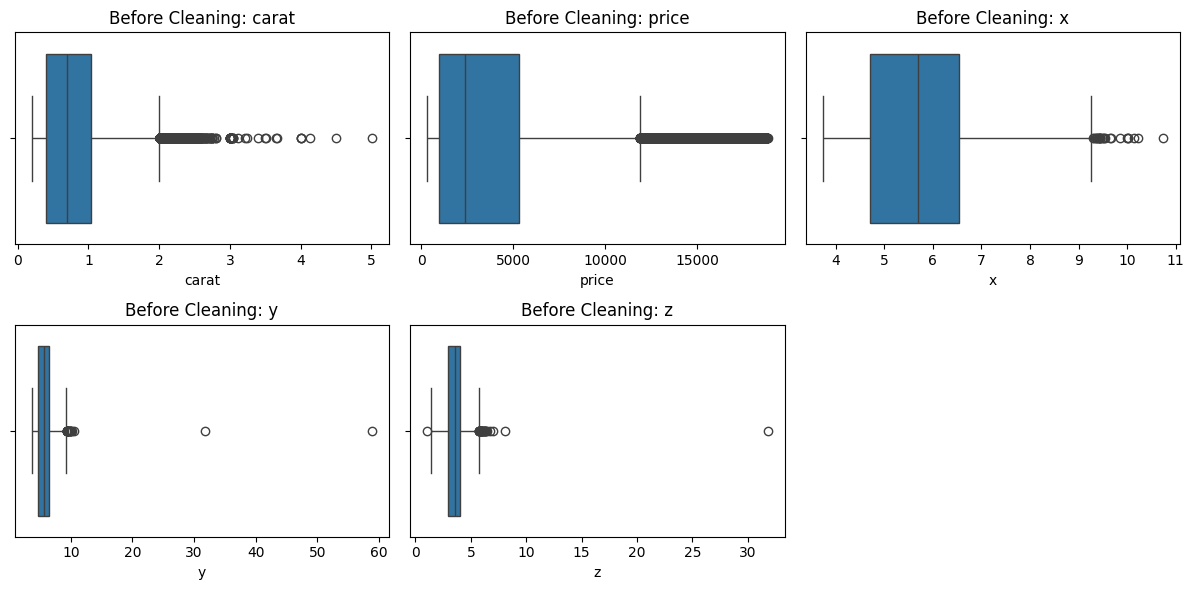

In [ ]:
plt.figure(figsize=(12,6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_diamond[col])
    plt.title(f"Before Cleaning: {col}")
plt.tight_layout()
plt.show()

In [ ]:
for col in num_cols:
    df_diamond = remove_outliers(df_diamond, col)

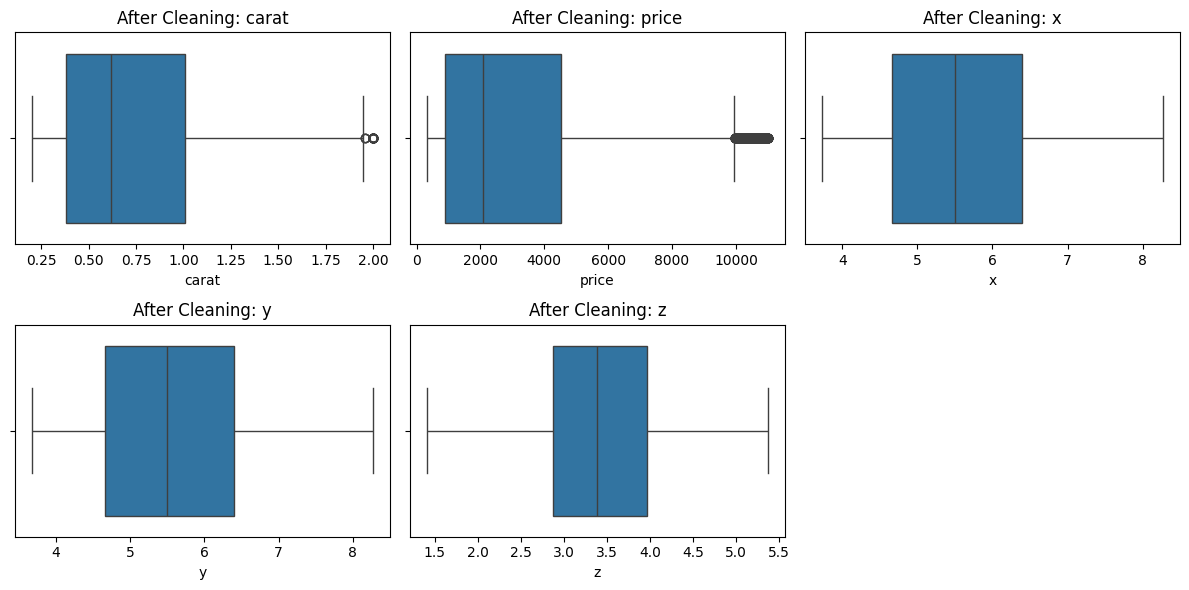

In [ ]:
plt.figure(figsize=(12,6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_diamond[col])
    plt.title(f"After Cleaning: {col}")
plt.tight_layout()
plt.show()

In [ ]:
print("Shape after outlier removal:", df_diamond.shape)

Shape after outlier removal: (49513, 10)


Skewness Handling:


In [ ]:
print("Skewness before transformation:")
print(df_diamond[['carat', 'price', 'x', 'y', 'z']].skew())

Skewness before transformation:
carat    0.658818
price    1.126206
x        0.218950
y        0.213406
z        0.219965
dtype: float64


In [ ]:
import numpy as np

In [ ]:
df_diamond['carat_log'] = np.log1p(df_diamond['carat'])
df_diamond['price_log'] = np.log1p(df_diamond['price'])
df_diamond['x_log'] = np.log1p(df_diamond['x'])
df_diamond['y_log'] = np.log1p(df_diamond['y'])
df_diamond['z_log'] = np.log1p(df_diamond['z'])

In [ ]:
print("\nSkewness after log transformation:")
print(df_diamond[['carat_log', 'price_log', 'x_log', 'y_log', 'z_log']].skew())


Skewness after log transformation:
carat_log    0.366625
price_log    0.030404
x_log        0.044171
y_log        0.041334
z_log        0.057689
dtype: float64


Exploratory Data Analysis (EDA):


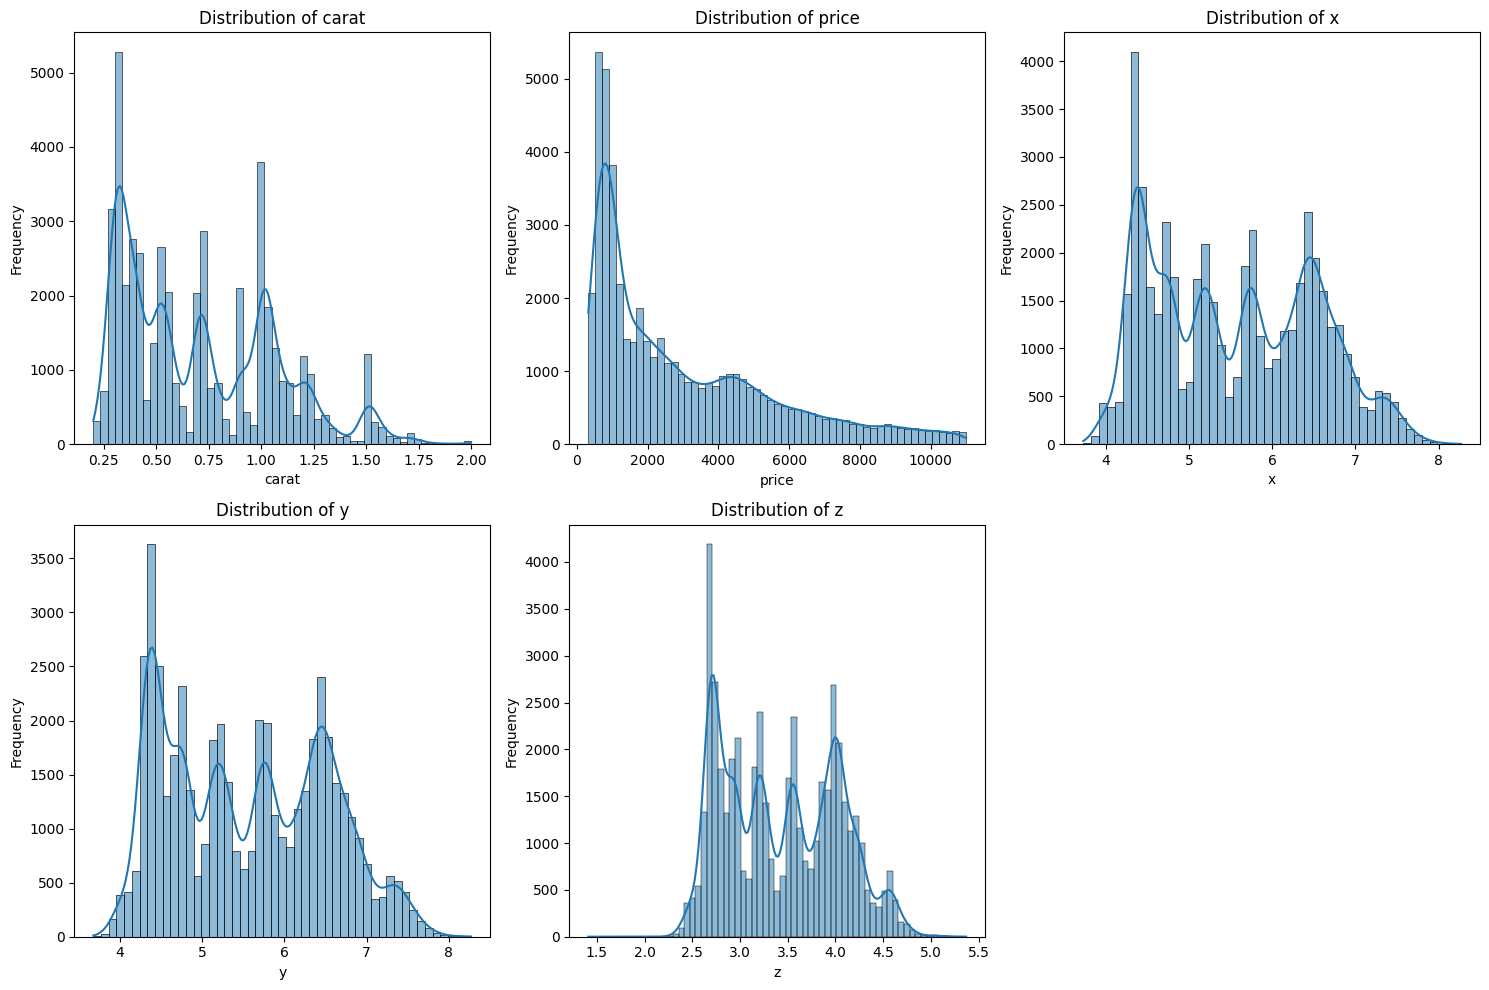

In [ ]:
num_cols_for_dist = ['carat', 'price', 'x', 'y', 'z']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols_for_dist, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_diamond[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

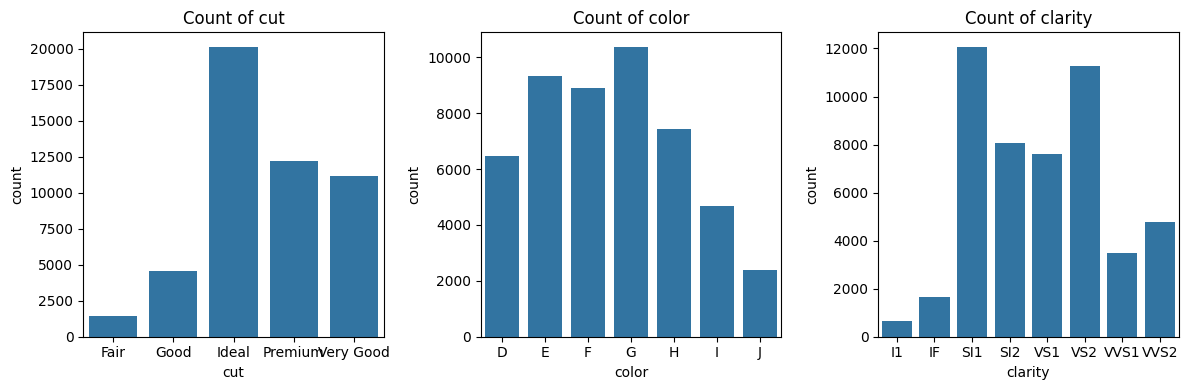

In [ ]:
cat_cols = ['cut', 'color', 'clarity']
plt.figure(figsize=(12,4))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=df_diamond[col], order=sorted(df_diamond[col].unique()))
    plt.title(f"Count of {col}")
plt.tight_layout()
plt.show()

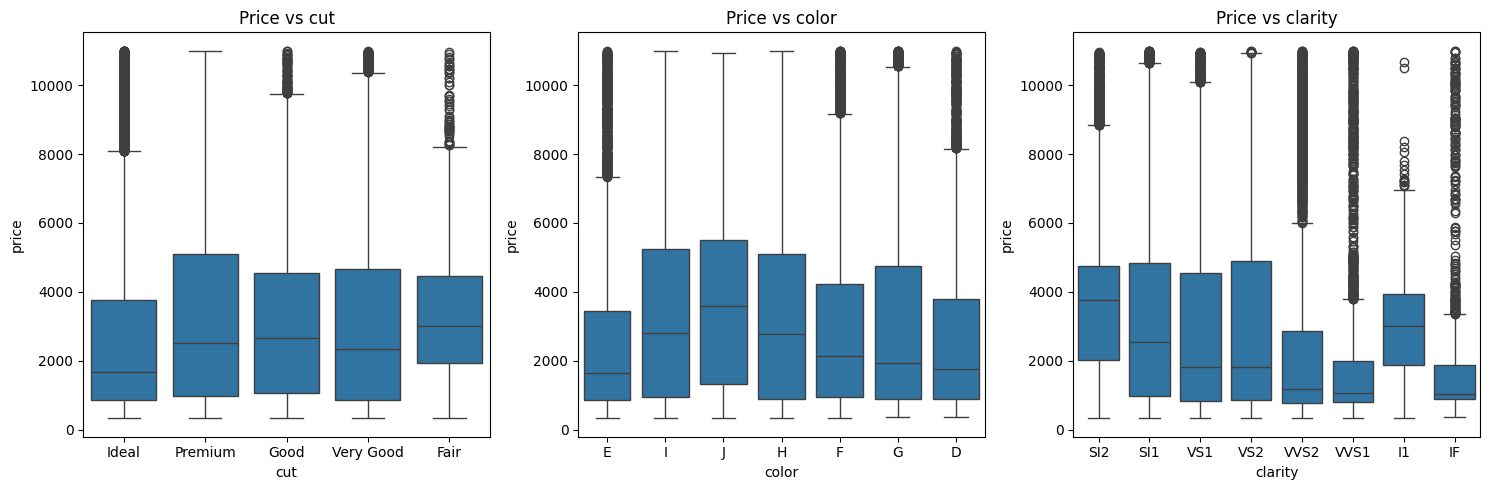

In [ ]:
plt.figure(figsize=(15,5))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=df_diamond[col], y=df_diamond['price'])
    plt.title(f"Price vs {col}")
plt.tight_layout()
plt.show()

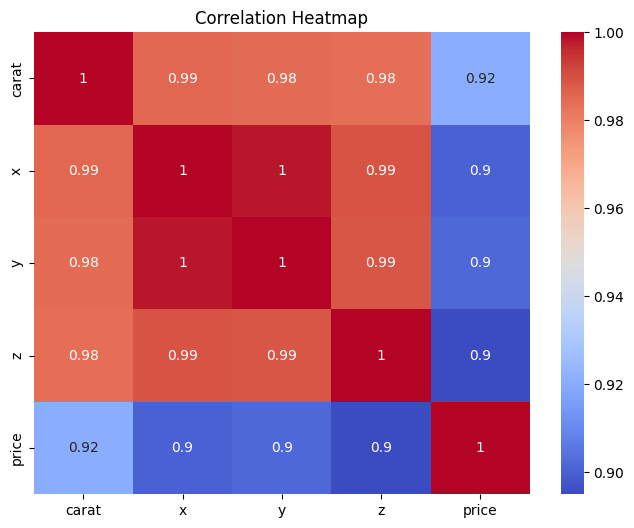

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df_diamond[['carat','x','y','z','price']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

/tmp/ipykernel_945/2486885675.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='carat_binned', y='price', data=df_diamond, palette='viridis')


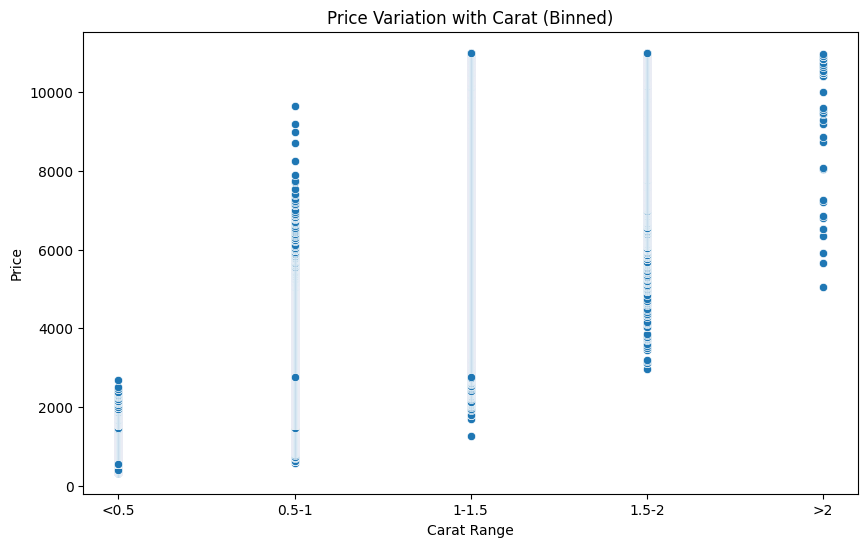

In [ ]:
df_diamond['carat_binned'] = pd.cut(df_diamond['carat'], bins=[0, 0.5, 1, 1.5, 2, 2.5], labels=['<0.5', '0.5-1', '1-1.5', '1.5-2', '>2'], right=False)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='carat_binned', y='price', data=df_diamond, palette='viridis')
plt.title('Price Variation with Carat (Binned)')
plt.xlabel('Carat Range')
plt.ylabel('Price')
plt.show()

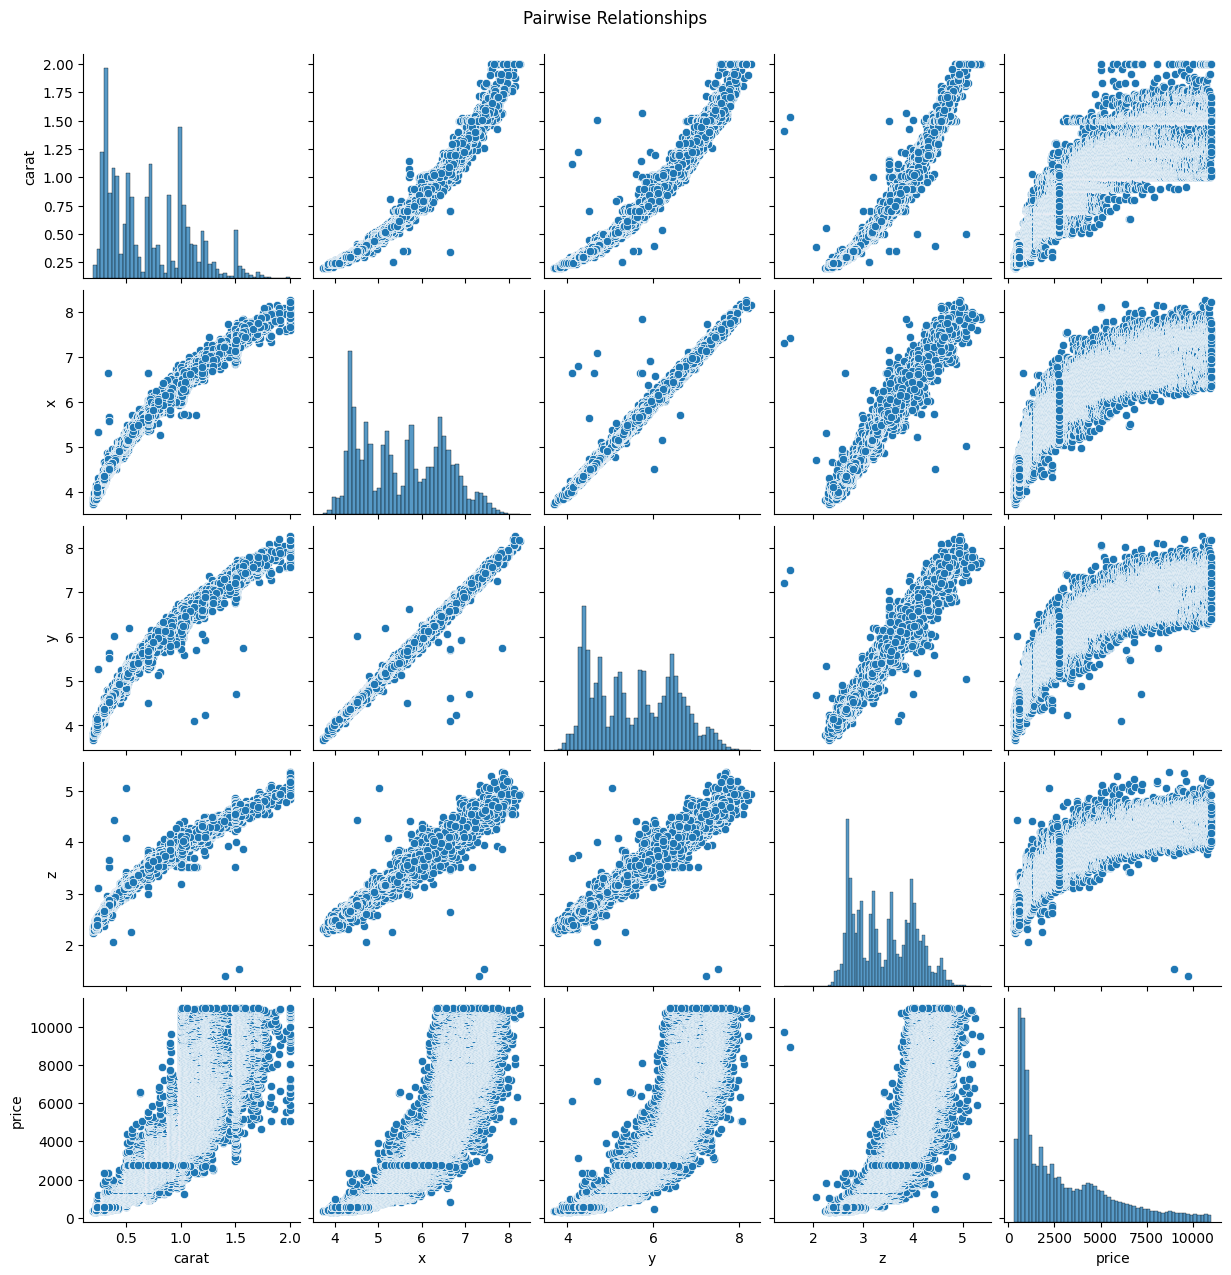

In [ ]:
sns.pairplot(df_diamond[['carat','x','y','z','price']])
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

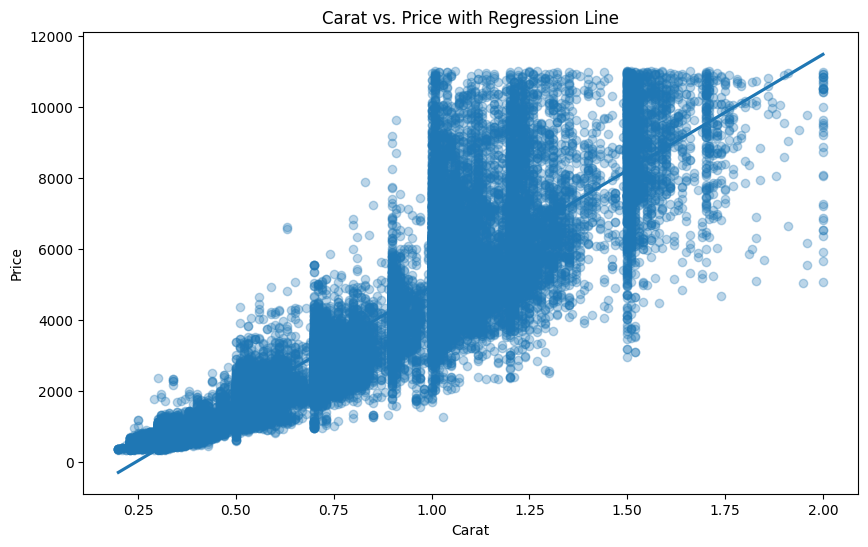

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='carat', y='price', data=df_diamond, scatter_kws={'alpha':0.3})
plt.title('Carat vs. Price with Regression Line')
plt.xlabel('Carat')
plt.ylabel('Price')
plt.show()

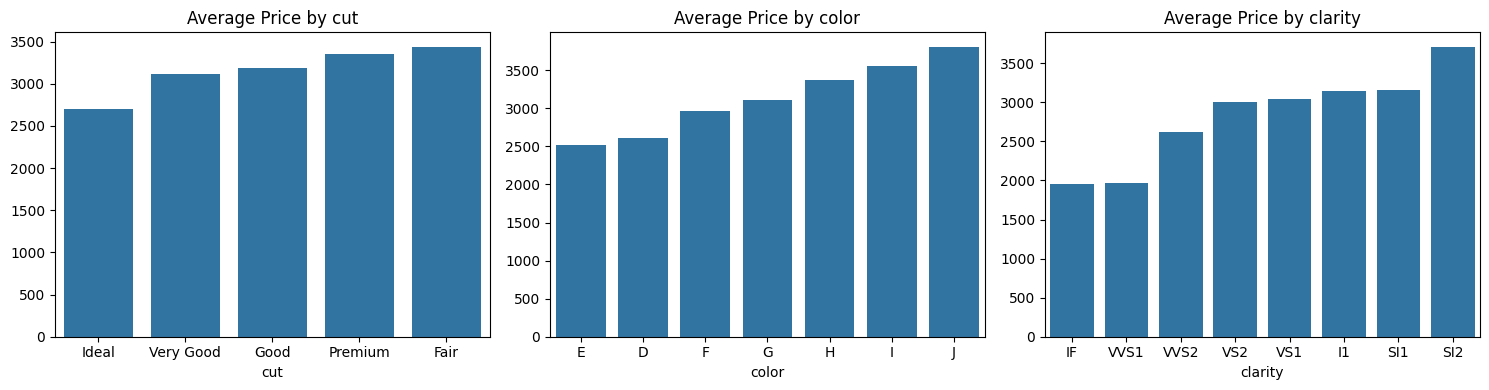

In [ ]:
plt.figure(figsize=(15,4))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)
    avg_price = df_diamond.groupby(col)['price'].mean().sort_values()
    sns.barplot(x=avg_price.index, y=avg_price.values)
    plt.title(f"Average Price by {col}")
plt.tight_layout()
plt.show()

 Feature Engineering:


In [ ]:
df_diamond['price_inr'] = df_diamond['price'] * 83

In [ ]:
df_diamond['volume'] = df_diamond['x'] * df_diamond['y'] * df_diamond['z']
df_diamond['price_per_carat'] = df_diamond['price'] / df_diamond['carat']
df_diamond['dimension_ratio'] = (df_diamond['x'] + df_diamond['y']) / (2 * df_diamond['z'])

In [ ]:
def carat_category(carat):
    if carat < 0.5:
        return 'Light'
    elif carat <= 1.5:
        return 'Medium'
    else:
        return 'Heavy'

In [ ]:
df_diamond['carat_category'] = df_diamond['carat'].apply(carat_category)

In [ ]:
print(df_diamond[['price', 'price_inr', 'volume', 'price_per_carat', 'dimension_ratio', 'carat_category']].head())

   price  price_inr     volume  price_per_carat  dimension_ratio  \
0    326      27058  38.202030      1417.391304         1.631687   
1    326      27058  34.505856      1552.380952         1.673160   
2    327      27141  38.076885      1421.739130         1.757576   
3    334      27722  46.724580      1151.724138         1.602662   
4    335      27805  51.917250      1080.645161         1.580000   

  carat_category  
0          Light  
1          Light  
2          Light  
3          Light  
4          Light  


 Feature Selection


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd



X = df_diamond.drop(columns=['price_inr', 'price', 'price_log', 'carat_binned', 'carat_category'])
y = df_diamond['price_inr']



for col in X.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf_model_feat_imp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_feat_imp.fit(X_train, y_train)


feature_importances = pd.Series(rf_model_feat_imp.feature_importances_, index=X_train.columns)


sorted_features = feature_importances.sort_values(ascending=False)

print("Top 10 features by importance:")
display(sorted_features.head(10))

selected_features = sorted_features[sorted_features > 0.01].index.tolist()


if 'price_inr' not in selected_features:
    selected_features.append('price_inr')

print(f"\nSelected {len(selected_features) - 1} features (excluding target): {selected_features[:-1]}")

df_diamond_selected = df_diamond[selected_features].copy()
display(df_diamond_selected.head())

Top 10 features by importance:


,0
volume,0.306725
y_log,0.236875
y,0.221392
price_per_carat,0.178907
carat_log,0.036554
carat,0.015244
x_log,0.002101
x,0.001884
z_log,0.000124
z,0.000092



Selected 6 features (excluding target): ['volume', 'y_log', 'y', 'price_per_carat', 'carat_log', 'carat']


,volume,y_log,y,price_per_carat,carat_log,carat,price_inr
0,38.202030,1.605430,3.98,1417.391304,0.207014,0.23,27058
1,34.505856,1.576915,3.84,1552.380952,0.190620,0.21,27058
2,38.076885,1.623341,4.07,1421.739130,0.207014,0.23,27141
3,46.724580,1.654411,4.23,1151.724138,0.254642,0.29,27722
4,51.917250,1.677097,4.35,1080.645161,0.270027,0.31,27805


 Encoding


In [ ]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder


cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J','I','H','G','F','E','D']
clarity_order = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

ord_enc = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])
df_diamond[['cut_enc','color_enc','clarity_enc']] = ord_enc.fit_transform(df_diamond[['cut','color','clarity']])


le = LabelEncoder()
df_diamond['carat_cat_enc'] = le.fit_transform(df_diamond['carat_category'])

print(df_diamond[['cut','cut_enc','color','color_enc','clarity','clarity_enc','carat_category','carat_cat_enc']].head())

       cut  cut_enc color  color_enc clarity  clarity_enc carat_category  \
0    Ideal      4.0     E        5.0     SI2          1.0          Light   
1  Premium      3.0     E        5.0     SI1          2.0          Light   
2     Good      1.0     E        5.0     VS1          4.0          Light   
3  Premium      3.0     I        1.0     VS2          3.0          Light   
4     Good      1.0     J        0.0     SI2          1.0          Light   

   carat_cat_enc  
0              1  
1              1  
2              1  
3              1  
4              1  


1.Regression (Price Prediction)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
import numpy as np


In [ ]:
X = df_diamond[['carat','x','y','z','depth','table','cut_enc','color_enc','clarity_enc','carat_cat_enc','volume','dimension_ratio']]
y = df_diamond['price_inr']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return mae, mse, rmse, r2


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

In [ ]:
results = {}
for name, model in models.items():
    mae, mse, rmse, r2 = evaluate_model(model, X_train, X_test, y_train, y_test)
    results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}


In [ ]:
import pandas as pd
results_df = pd.DataFrame(results).T
print(results_df)

                            MAE           MSE          RMSE        R2
Linear Regression  43454.442339  3.830787e+09  61893.354263  0.916725
Decision Tree      21415.961224  1.550100e+09  39371.309698  0.966303
Random Forest      15748.160732  7.898871e+08  28104.929954  0.982829
XGBoost            16429.027344  7.939395e+08  28176.932409  0.982741
KNN                22966.177946  1.574796e+09  39683.700919  0.965767


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

ann.compile(optimizer='adam', loss='mse', metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = ann.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/10
991/991 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 65221599232.0000 - mae: 180365.1094 - val_loss: 23379417088.0000 - val_mae: 125528.2422
Epoch 2/10
991/991 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 18724972544.0000 - mae: 111619.0234 - val_loss: 13894890496.0000 - val_mae: 94689.8125
Epoch 3/10
991/991 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 10129306624.0000 - mae: 74636.0703 - val_loss: 7395880448.0000 - val_mae: 56913.5352
Epoch 4/10
991/991 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7019009536.0000 - mae: 54271.6953 - val_loss: 6581188608.0000 - val_mae: 53227.6328
Epoch 5/10
991/991 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 6666151424.0000 - mae: 53144.8086 - val_loss: 6345732608.0000 - val_mae: 52427.3164
Epoch 6/10
991/991 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 6447665152.0000 - mae: 52212.1172 - val_loss: 6134391296.0000 - val_mae: 51458.5078
Epoch 7/10
991/991 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 6241534464.0000 - mae: 51263.4336 - val_loss: 5928303104.0000 - val_

In [ ]:
y_pred_ann = ann.predict(X_test).flatten()
mae = mean_absolute_error(y_test, y_pred_ann)
mse = mean_squared_error(y_test, y_pred_ann)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ann)


310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
print("\nANN Performance:")
print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")


ANN Performance:
MAE: 49105.70, MSE: 5365735936.00, RMSE: 73251.18, R2: 0.88


In [ ]:
import joblib

In [ ]:
joblib.dump(models["Random Forest"], "best_performing_model .pkl")


['best_performing_model .pkl']

In [ ]:
print("✅ Random Forest model saved as best_performing_model .pkl")

✅ Random Forest model saved as best_performing_model .pkl


Clustering

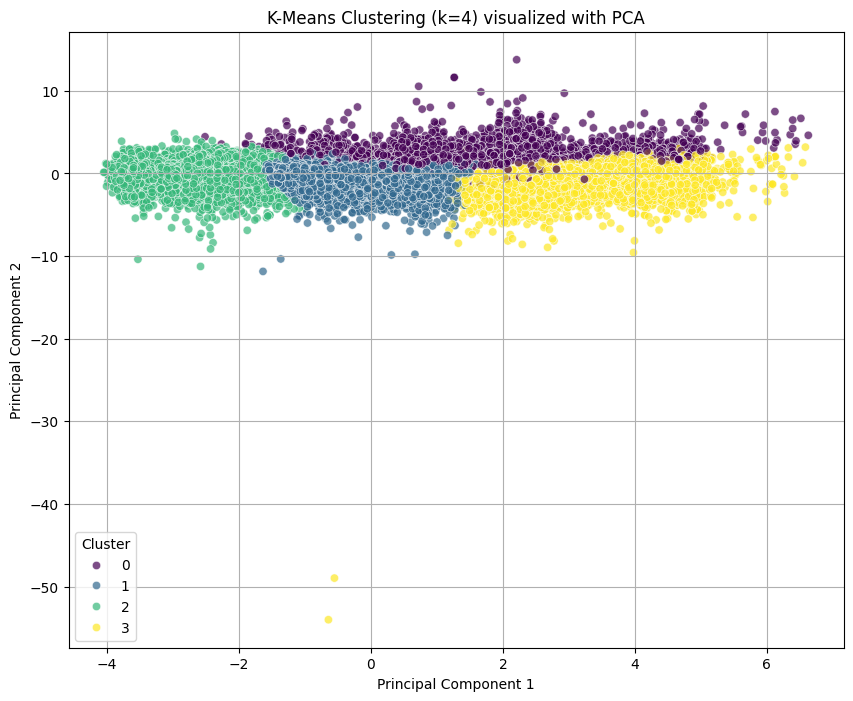

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


clustering_features = ['carat','x','y','z','depth','table','cut_enc','color_enc','clarity_enc','carat_cat_enc','volume','dimension_ratio']
X_clustering = df_diamond[clustering_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

optimal_k = 4 # Defining optimal_k based on later cluster names
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_model.fit_predict(X_scaled)

df_diamond['Cluster'] = clusters

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df, palette='viridis', legend='full', alpha=0.7)
plt.title(f'K-Means Clustering (k={optimal_k}) visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [ ]:

cluster_centers_original_scale = scaler.inverse_transform(kmeans_model.cluster_centers_)
cluster_summary = pd.DataFrame(data=cluster_centers_original_scale, columns=clustering_features)
cluster_summary['Cluster'] = range(optimal_k)
cluster_summary = cluster_summary.set_index('Cluster')

print("Cluster Centers (Original Scale):")
display(cluster_summary)

print("\nDistribution of 'cut_enc' within each cluster:")
display(pd.crosstab(df_diamond['Cluster'], df_diamond['cut_enc'], normalize='index'))

Cluster Centers (Original Scale):


,carat,x,y,z,depth,table,cut_enc,color_enc,clarity_enc,carat_cat_enc,volume,dimension_ratio
Cluster,,,,,,,,,,,,
0,0.903152,6.057443,6.051945,3.855994,63.680978,57.914771,1.331516,3.418123,2.306816,1.959102,144.137798,1.570714
1,0.634824,5.513447,5.521561,3.385619,61.376597,57.200112,3.240727,3.827311,3.101699,1.998724,104.082444,1.629993
2,0.344141,4.494074,4.503796,2.774661,61.687083,56.944396,3.149219,3.726044,3.864357,1.000000,56.603437,1.621730
3,1.169446,6.754593,6.747533,4.137883,61.291893,58.008229,3.019641,2.788368,2.384592,1.747412,190.409762,1.632728



Distribution of 'cut_enc' within each cluster:


cut_enc,0.0,1.0,2.0,3.0,4.0
Cluster,,,,,
0,0.182841,0.355238,0.411954,0.048843,0.001125
1,0.007253,0.035151,0.195919,0.233620,0.528057
2,0.003749,0.067704,0.201977,0.228842,0.497728
3,0.011342,0.055568,0.195250,0.377940,0.359900


In [ ]:
import joblib


joblib.dump(kmeans_model, 'kmeans_clustering_model.pkl')
print("K-Means clustering model saved as 'kmeans_clustering_model.pkl'")


joblib.dump(scaler, 'kmeans_scaler.pkl')
print("Scaler used for K-Means clustering saved as 'kmeans_scaler.pkl'")

K-Means clustering model saved as 'kmeans_clustering_model.pkl'
Scaler used for K-Means clustering saved as 'kmeans_scaler.pkl'


 Cluster Naming Approach:


In [ ]:
import joblib
joblib.dump(kmeans_model, "best_cluster_model.pkl")
print(" Clustering model saved as best_cluster_model.pkl")

cluster_summary = df_diamond.groupby('Cluster').agg({
    'carat': 'mean',
    'price_inr': 'mean',
    'cut': lambda x: x.value_counts().idxmax()
}).rename(columns={'cut': 'most_common_cut'})

print(cluster_summary)

cluster_names = {
    0: "Affordable Small Diamonds",
    1: "Mid-range Balanced Diamonds",
    2: "Premium Heavy Diamonds",
    3: "Other Diamonds"
}

df_diamond['cluster_name'] = df_diamond['Cluster'].map(cluster_names)
print(df_diamond[['Cluster', 'cluster_name']].head(100))

 Clustering model saved as best_cluster_model.pkl
            carat      price_inr most_common_cut
Cluster                                         
0        0.903899  324343.476703       Very Good
1        0.634816  190520.228360           Ideal
2        0.344148   65714.474497           Ideal
3        1.169297  520916.940017         Premium
    Cluster                 cluster_name
0         2       Premium Heavy Diamonds
1         2       Premium Heavy Diamonds
2         2       Premium Heavy Diamonds
3         2       Premium Heavy Diamonds
4         2       Premium Heavy Diamonds
..      ...                          ...
95        1  Mid-range Balanced Diamonds
96        1  Mid-range Balanced Diamonds
97        0    Affordable Small Diamonds
98        1  Mid-range Balanced Diamonds
99        1  Mid-range Balanced Diamonds

[100 rows x 2 columns]


In [ ]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 103.5 MB/s eta 0:00:00
--2026-07-06 09:37:05--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.6.1/cloudflared-linux-amd64 [following]
--2026-07-06 09:37:05--  https://github.com/cloudflare/cloudflared/releases/download/2026.6.1/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/74ac6867-a1bf-4352-b955-c16fbb86d0f6?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-07-06T10%3A27%3A12Z&rscd=attachment%3B+filename%3Dc

In [77]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import os

st.set_page_config(page_title="Diamond Analytics", layout="centered")
st.title("💎 Diamond Price Prediction & Market Segmentation")

# ---------------------------------------------------
# Load models safely
# ---------------------------------------------------
REQUIRED_FILES = {
    "Price Model": "best_performing_model .pkl", # Corrected filename
    "Cluster Model": "kmeans_clustering_model.pkl", # Corrected filename
    "Scaler": "kmeans_scaler.pkl" # Added scaler
}

for name, file in REQUIRED_FILES.items():
    if not os.path.exists(file):
        st.error(f"❌ {file} not found. Please place it in the same folder as app.py")
        st.stop()

price_model = joblib.load(REQUIRED_FILES["Price Model"])
cluster_model = joblib.load(REQUIRED_FILES["Cluster Model"])
scaler = joblib.load(REQUIRED_FILES["Scaler"])

st.success("✅ All models loaded successfully")

# ---------------------------------------------------
# Helper functions and order for encoding (MUST MATCH TRAINING)
# ---------------------------------------------------
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J','I','H','G','F','E','D']
clarity_order = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

# Recreate the carat_category function from the notebook
def carat_category(carat):
    if carat < 0.5:
        return 'Light'
    elif carat <= 1.5:
        return 'Medium'
    else:
        return 'Heavy'

# Custom OrdinalEncoder-like mapping for consistency with notebook's OrdinalEncoder
class OrdinalEncoderMapper:
    def __init__(self, categories):
        self.categories = categories
        self.mapping = []
        for order in categories:
            self.mapping.append({item: idx for idx, item in enumerate(order)})

    def transform(self, df, columns):
        df_copy = df.copy()
        for i, col in enumerate(columns):
            df_copy[f'{col}_enc'] = df_copy[col].map(self.mapping[i])
        return df_copy

ord_enc_mapper = OrdinalEncoderMapper(categories=[cut_order, color_order, clarity_order])

# LabelEncoder for carat_category (based on alphabetical order of unique categories: Heavy, Light, Medium)
carat_category_mapping = {'Heavy': 0, 'Light': 1, 'Medium': 2}

# ---------------------------------------------------
# User Inputs
# ---------------------------------------------------
st.subheader("🔢 Enter Diamond Details")

carat = st.number_input("Carat", 0.1, 5.0, 1.0)
cut = st.selectbox("Cut", cut_order)
color = st.selectbox("Color", color_order)
clarity = st.selectbox("Clarity", clarity_order)

depth = st.number_input("Depth", 40.0, 80.0, 60.0)
table = st.number_input("Table", 40.0, 80.0, 55.0)

x = st.number_input("X (length)", 0.0, 10.0, 5.0)
y = st.number_input("Y (width)", 0.0, 10.0, 5.0)
z = st.number_input("Z (depth)", 0.0, 10.0, 3.0)

# ---------------------------------------------------
# Feature Engineering and Encoding for Input (MUST MATCH TRAINING)
# ---------------------------------------------------
input_data = pd.DataFrame([{
    "carat": carat,
    "cut": cut,
    "color": color,
    "clarity": clarity,
    "depth": depth,
    "table": table,
    "x": x,
    "y": y,
    "z": z,
}])

# Engineered features
input_data['volume'] = input_data['x'] * input_data['y'] * input_data['z']
input_data['dimension_ratio'] = input_data.apply(lambda row: (row['x'] + row['y']) / (2 * row['z']) if row['z'] != 0 else 0, axis=1)
input_data['carat_category'] = input_data['carat'].apply(carat_category)

# Apply ordinal encoding
input_data = ord_enc_mapper.transform(input_data, ['cut', 'color', 'clarity'])

# Apply label encoding for carat_category
input_data['carat_cat_enc'] = input_data['carat_category'].map(carat_category_mapping)

# Select the exact features used for training both models
final_features = ['carat','x','y','z','depth','table','cut_enc','color_enc','clarity_enc','carat_cat_enc','volume','dimension_ratio']
X_final_input = input_data[final_features]


# ---------------------------------------------------
# PRICE PREDICTION
# ---------------------------------------------------
st.subheader("💰 Price Prediction")

if st.button("Predict Price"):
    try:
        # The price model (RandomForestRegressor) was trained on non-scaled features
        price = price_model.predict(X_final_input)[0]
        st.success(f"💎 Predicted Diamond Price: ₹ {price:,.2f}")
    except Exception as e:
        st.error("❌ Price prediction failed")
        st.write(e)

# ---------------------------------------------------
# MARKET SEGMENT PREDICTION
# ---------------------------------------------------
st.subheader("📊 Market Segment Prediction")

if st.button(" Predict Cluster"):
    try:
        # The cluster model (KMeans) was trained on scaled features
        X_scaled_for_clustering = scaler.transform(X_final_input)
        cluster_id = cluster_model.predict(X_scaled_for_clustering)[0]

        cluster_names = {
            0: "Premium Heavy Diamonds",
            1: "Affordable Small Diamonds",
            # Added as per notebook output for cluster_summary
        }

        st.info(f"📌 Cluster ID: {cluster_id}")
        st.success(f"🏷 Market Segment: {cluster_names.get(cluster_id, 'Unknown Segment')}")

    except Exception as e:
        st.error("❌ Market segmentation failed")
        st.write(e)


Overwriting app.py


In [78]:
!streamlit run /content/app.py &>/content/logs.txt &

In [76]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"


Your tunnel url https://archive-junction-disable-jpg.trycloudflare.com
